EP2 - Reconhecimento de Folhas de Plantas

Parte 3: Rede Neural Probabilística (PNN)

Ísis Ardisson Logullo - 7577410

1 - Carregamento do Dataset

Mapeamento de cada tipo de planta para os seus respectivos intervalos de arquivos, conforme especificado na tabela. As imagens são carregadas do arquivo Leaves.zip encontrado no enunciado do EP2, estruturando-as em um dicionário para fácil acesso nas etapas subsequentes. É necessário ter o arquivo baixado na mesma pasta onde se encontra esse jupiter notebook.

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['image.cmap'] = 'gray'

ARQUIVO_ZIP_LOCAL = "Leaves.zip"
DIRETORIO_DATASET = "Leaves"

def extrair_e_carregar_imagens_local(arquivo_zip, diretorio_destino):
    if not os.path.exists(diretorio_destino):
        print(f"Pasta '{diretorio_destino}' não encontrada.")

        if os.path.exists(arquivo_zip):
            print(f"Arquivo '{arquivo_zip}' detectado localmente. Iniciando extração...")
            try:
                with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
                    zip_ref.extractall(diretorio_destino)
                print("Extração concluída com sucesso!")
            except Exception as e:
                print(f"Erro ao tentar extrair o arquivo ZIP: {e}")
                return {}
        else:
            print(f"Erro: O arquivo '{arquivo_zip}' não foi encontrado na pasta atual.")
            print("Certifique-se de que o arquivo ZIP está exatamente no mesmo diretório deste script.")
            return {}
    else:
        print(f"A pasta '{diretorio_destino}' já existe. Pulando extração e lendo os arquivos.")

    dataset_direto = {}

    print("\nIniciando o carregamento das imagens...")
    for raiz, _, arquivos in os.walk(diretorio_destino):
        for arquivo in arquivos:
            nome_puro, extensao = os.path.splitext(arquivo)

            if nome_puro.isdigit() and extensao.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                numero_id = int(nome_puro)
                caminho_completo = os.path.join(raiz, arquivo)

                try:
                    img_array = plt.imread(caminho_completo)
                    dataset_direto[numero_id] = img_array
                except Exception as err:
                    print(f"Erro ao ler o arquivo {arquivo}: {err}")

    print(f"Concluído! Total de imagens salvas na memória: {len(dataset_direto)}")
    return dataset_direto

folhas_dados_direto = extrair_e_carregar_imagens_local(ARQUIVO_ZIP_LOCAL, DIRETORIO_DATASET)

Pasta 'Leaves' não encontrada.
Arquivo 'Leaves.zip' detectado localmente. Iniciando extração...
Extração concluída com sucesso!

Iniciando o carregamento das imagens...
Concluído! Total de imagens salvas na memória: 1907


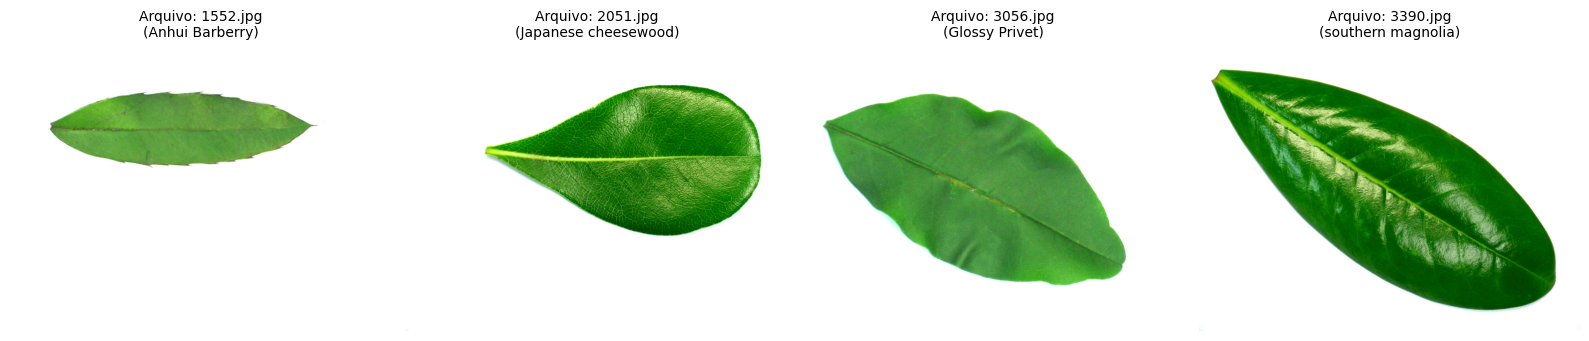

In [108]:
MAPEAMENTO_PLANTAS = {
    1: ("pubescent bamboo", 1001, 1059),
    2: ("Chinese horse chestnut", 1060, 1122),
    3: ("Anhui Barberry", 1552, 1616),
    4: ("Chinese redbud", 1123, 1194),
    5: ("true indigo", 1195, 1267),
    6: ("Japanese maple", 1268, 1323),
    7: ("Nanmu", 1324, 1385),
    8: ("castor aralia", 1386, 1437),
    9: ("Chinese cinnamon", 1497, 1551),
    10: ("goldenrain tree", 1438, 1496),
    11: ("Bigfruited -Holly", 2001, 2050),
    12: ("Japanese cheesewood", 2051, 2113),
    14: ("wintersweet", 2114, 2165),
    15: ("camphortree", 2166, 2230),
    16: ("Japan Arrowwood", 2231, 2290),
    17: ("sweet osmanthus", 2291, 2346),
    18: ("deodar", 2347, 2423),
    19: ("ginkgo, maidenhair tree", 2424, 2485),
    20: ("Crape myrtle, Crepe myrtle", 2486, 2546),
    21: ("oleander", 2547, 2612),
    22: ("yew plum pine", 2616, 2675),
    23: ("Japanese Flowering Cherry", 3001, 3055),
    24: ("Glossy Privet", 3056, 3110),
    25: ("Chinese Toon", 3111, 3175),
    26: ("peach", 3176, 3229),
    27: ("Ford Woodlotus", 3230, 3281),
    28: ("trident maple", 3282, 3334),
    29: ("Beale's barberry", 3335, 3389),
    30: ("southern magnolia", 3390, 3446),
    31: ("Canadian poplar", 3447, 3510),
    32: ("Chinese tulip tree", 3511, 3563),
    33: ("tangerine", 3566, 3621)
}

def obter_nome_especie_por_id_arquivo(id_arquivo):
    """
    Varre o MAPEAMENTO_PLANTAS para descobrir a espécie com base no
    intervalo numérico [ID_inicio, ID_fim].
    """
    for chave_especie, (nome, inicio, fim) in MAPEAMENTO_PLANTAS.items():
        if inicio <= id_arquivo <= fim:
            return nome
    return "Espécie Desconhecida"


def visualizar_folhas_por_numero(dataset, numeros_para_mostrar):
    qtd = len(numeros_para_mostrar)
    if qtd == 0:
        return

    fig, axes = plt.subplots(1, qtd, figsize=(4 * qtd, 4.5))
    if qtd == 1:
        axes = [axes]

    for idx, num in enumerate(numeros_para_mostrar):
        nome_especie = obter_nome_especie_por_id_arquivo(num)

        if num in dataset:
            img = dataset[num]
            axes[idx].imshow(img)
            axes[idx].set_title(f"Arquivo: {num}.jpg\n({nome_especie})", fontsize=10)
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"Arquivo {num}.jpg\nnão encontrado",
                           ha='center', va='center', color='red')
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


# Planta 3  (Anhui Barberry): 1552
# Planta 12 (Japanese cheesewood): 2051
# Planta 24 (Glossy Privet): 3056
# Planta 30 (southern magnolia): 3390
IDS_REAIS_TESTE = [1552, 2051, 3056, 3390]

if 'folhas_dados_direto' in globals() and folhas_dados_direto:
    visualizar_folhas_por_numero(folhas_dados_direto, numeros_para_mostrar=IDS_REAIS_TESTE)

2 - Extração de Características

Para criar a PNN, é preciso transformar cada imagem de folha em um vetor de características numéricas.
- Área ($A$): Soma de todos os pixels brancos da folha (assumindo que o fundo é 0 e a folha é $>0$).

- Perímetro ($P$): Aproximação encontrando os pixels de borda através da diferença com vizinhos desalinhados.

- Comprimento ($L$) e Largura ($W_l$): Dimensões máximas da folha projetadas nos eixos horizontal e vertical após limpeza.

- Fator de Forma (Form Factor): $\frac{4\pi A}{P^2}$.

Extração Concluída! 1907 vetores morfológicos gerados.



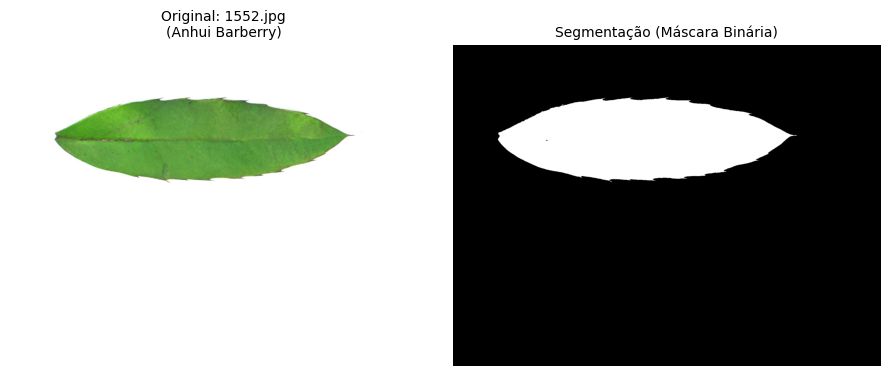

VETOR DE CARACTERÍSTICAS EXTRAÍDO (ID 1552):
Proporção (C/L): 0.2838
Solidez da Folha: 0.6949
Projeções Horizontais (Bins 1-10): [0.2819 0.9574 0.     0.0012 0.0018 0.0023 0.0026 0.0031 0.0033 0.0035]
Projeções Verticais (Bins 11-22): [0.0036 0.0038 0.004  0.0042 0.0044 0.0045 0.0044 0.0043 0.0043 0.0041]
--------------------------------------------------------------------------------


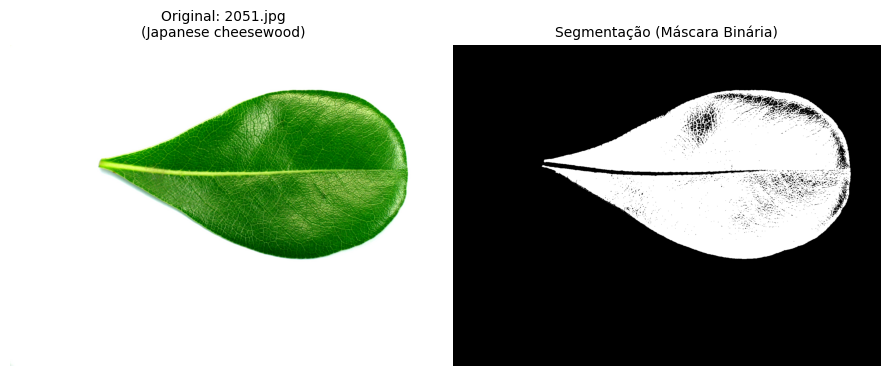

VETOR DE CARACTERÍSTICAS EXTRAÍDO (ID 2051):
Proporção (C/L): 0.5472
Solidez da Folha: 0.6022
Projeções Horizontais (Bins 1-10): [3.300e-03 8.061e-01 1.000e-04 6.000e-04 8.000e-04 9.000e-04 1.000e-03
 1.300e-03 1.500e-03 1.700e-03]
Projeções Verticais (Bins 11-22): [0.0018 0.002  0.0021 0.0023 0.0025 0.0023 0.0018 0.0023 0.0022 0.0022]
--------------------------------------------------------------------------------


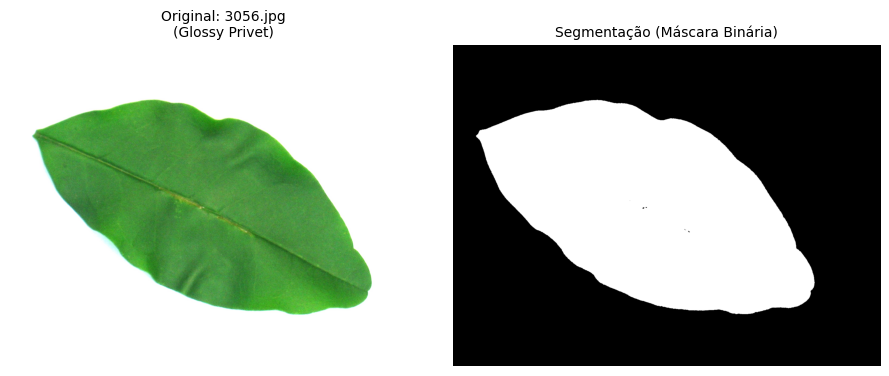

VETOR DE CARACTERÍSTICAS EXTRAÍDO (ID 3056):
Proporção (C/L): 0.6327
Solidez da Folha: 0.6423
Projeções Horizontais (Bins 1-10): [4.326e-01 8.642e-01 0.000e+00 5.000e-04 7.000e-04 1.100e-03 1.300e-03
 1.400e-03 1.400e-03 1.400e-03]
Projeções Verticais (Bins 11-22): [0.0014 0.0015 0.0015 0.0015 0.0015 0.0015 0.0015 0.0015 0.0015 0.0015]
--------------------------------------------------------------------------------


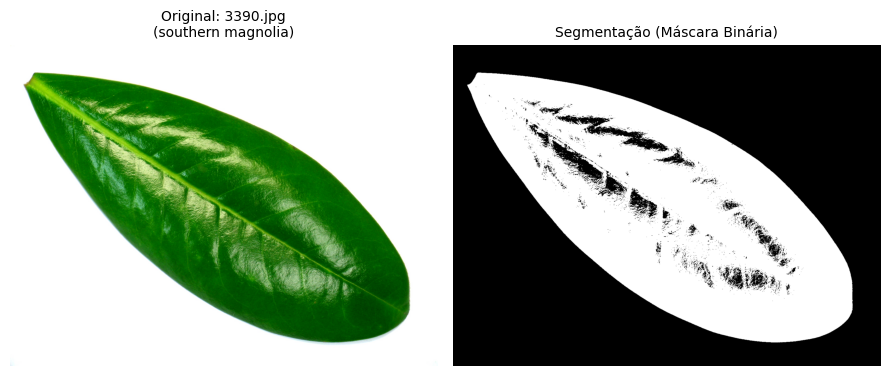

VETOR DE CARACTERÍSTICAS EXTRAÍDO (ID 3390):
Proporção (C/L): 0.6997
Solidez da Folha: 0.5129
Projeções Horizontais (Bins 1-10): [3.300e-03 9.119e-01 0.000e+00 5.000e-04 7.000e-04 8.000e-04 8.000e-04
 7.000e-04 9.000e-04 1.000e-03]
Projeções Verticais (Bins 11-22): [0.001  0.0011 0.0011 0.0012 0.0012 0.0012 0.0012 0.0012 0.0012 0.0013]
--------------------------------------------------------------------------------


In [134]:
import numpy as np
import matplotlib.pyplot as plt

def extrair_vetor_caracteristicas_visual(img, retornar_mascara=False):
    if len(img.shape) == 3:
        img_gray = np.mean(img, axis=2)
    else:
        img_gray = img.copy()

    binaria = img_gray > (np.min(img_gray) + np.max(img_gray)) / 2
    borda_soma = np.sum(binaria[0, :]) + np.sum(binaria[-1, :]) + np.sum(binaria[:, 0]) + np.sum(binaria[:, -1])
    if borda_soma > (binaria.shape[0] * 2 + binaria.shape[1] * 2) / 2:
        binaria = ~binaria

    area = float(np.sum(binaria))

    if area == 0:
        features = np.zeros(78)
        return (features, binaria) if retornar_mascara else features

    y_indices, x_indices = np.where(binaria)
    cy = np.mean(y_indices)
    cx = np.mean(x_indices)

    mu20 = np.mean((x_indices - cx) ** 2)
    mu02 = np.mean((y_indices - cy) ** 2)
    mu11 = np.mean((x_indices - cx) * (y_indices - cy))

    hu1 = mu20 + mu02
    hu2 = (mu20 - mu02)**2 + 4 * (mu11**2)

    img_norm = img_gray / 255.0
    pixels_folha = img_norm[binaria]

    media_tom = np.mean(pixels_folha)
    desvio_tom = np.std(pixels_folha)

    grad_x = np.diff(img_norm, axis=1)
    grad_y = np.diff(img_norm, axis=0)
    mascara_x = binaria[:, :-1] & binaria[:, 1:]
    mascara_y = binaria[:-1, :] & binaria[1:, :]

    textura_grad_x = np.std(grad_x[mascara_x]) if np.sum(mascara_x) > 0 else 0.0
    textura_grad_y = np.std(grad_y[mascara_y]) if np.sum(mascara_y) > 0 else 0.0

    textura_caract = np.array([media_tom, desvio_tom, textura_grad_x, textura_grad_y, hu1, hu2])

    linhas = np.any(binaria, axis=1)
    colunas = np.any(binaria, axis=0)

    if np.any(linhas) and np.any(colunas):
        ymin, ymax = np.where(linhas)[0][[0, -1]]
        xmin, xmax = np.where(colunas)[0][[0, -1]]
        comprimento = float(ymax - ymin + 1)
        largura = float(xmax - xmin + 1)
        folha_recortada = binaria[ymin:ymax+1, xmin:xmax+1]
    else:
        comprimento, largura = 1.0, 1.0
        folha_recortada = binaria

    proj_h = np.sum(folha_recortada, axis=1)
    proj_v = np.sum(folha_recortada, axis=0)

    bins = 30
    ind_h = np.linspace(0, len(proj_h) - 1, bins).astype(int)
    ind_v = np.linspace(0, len(proj_v) - 1, bins).astype(int)

    caract_projecao = np.concatenate([proj_h[ind_h] / area, proj_v[ind_v] / area])

    proporcao = comprimento / largura
    solidez = area / (comprimento * largura)

    perimetro = np.sum(binaria[:, :-1] != binaria[:, 1:]) + np.sum(binaria[:-1, :] != binaria[1:, :])
    circularidade = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0.0

    termo_raiz = np.sqrt((mu20 - mu02)**2 + 4 * (mu11**2))
    eixo_maior = np.sqrt(2 * (mu20 + mu02 + termo_raiz))
    eixo_menor = np.sqrt(2 * (mu20 + mu02 - termo_raiz))
    excentricidade = np.sqrt(1 - (eixo_menor / eixo_maior)**2) if eixo_maior > 0 and (mu20 + mu02 >= termo_raiz) else 0.0

    vetor_final = np.concatenate([[proporcao, solidez, circularidade, excentricidade], caract_projecao, textura_caract])

    if retornar_mascara:
        return vetor_final, binaria
    return vetor_final

caracteristicas_folhas = {}
for id_arq, img in folhas_dados_direto.items():
    caracteristicas_folhas[id_arq] = extrair_vetor_caracteristicas_visual(img, retornar_mascara=False)

print(f"Extração Concluída! {len(caracteristicas_folhas)} vetores morfológicos gerados.\n")

def diagnosticar_extracao_visual(dataset, ids_para_analisar):
    for id_arq in ids_para_analisar:
        if id_arq not in dataset:
            print(f"Arquivo {id_arq}.jpg não encontrado para inspeção visual.")
            continue

        img_original = dataset[id_arq]
        nome_especie = obter_nome_especie_por_id_arquivo(id_arq)

        vetor, mascara = extrair_vetor_caracteristicas_visual(img_original, retornar_mascara=True)
        fig, axes = plt.subplots(1, 2, figsize=(9, 4))

        axes[0].imshow(img_original, cmap='gray' if len(img_original.shape)==2 else None)
        axes[0].set_title(f"Original: {id_arq}.jpg\n({nome_especie})", fontsize=10)
        axes[0].axis('off')

        axes[1].imshow(mascara, cmap='gray')
        axes[1].set_title(f"Segmentação (Máscara Binária)", fontsize=10)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"VETOR DE CARACTERÍSTICAS EXTRAÍDO (ID {id_arq}):")
        print(f"Proporção (C/L): {vetor[0]:.4f}")
        print(f"Solidez da Folha: {vetor[1]:.4f}")
        print(f"Projeções Horizontais (Bins 1-10): {np.round(vetor[2:12], 4)}")
        print(f"Projeções Verticais (Bins 11-22): {np.round(vetor[12:22], 4)}")
        print("-" * 80)

IDS_INSPECAO = [1552, 2051, 3056, 3390]
diagnosticar_extracao_visual(folhas_dados_direto, IDS_INSPECAO)

3 - Divisão de Treino e Teste

Para cada tipo de planta listado no MAPEAMENTO_PLANTAS, é usado exatamente as últimas 10 folhas do intervalo total para compor o conjunto de testes. O restante será alocado no conjunto de treinamento.

In [135]:
X_train, y_train, X_test, y_test = [], [], [], []

for classe_id, (nome, inicio, fim) in MAPEAMENTO_PLANTAS.items():
    ids_classe_existentes = [i for i in range(inicio, fim + 1) if i in caracteristicas_folhas]
    ids_classe_existentes.sort()
    ids_treino = ids_classe_existentes[:-10]
    ids_teste = ids_classe_existentes[-10:]

    for i in ids_treino:
        X_train.append(caracteristicas_folhas[i])
        y_train.append(classe_id)
    for i in ids_teste:
        X_test.append(caracteristicas_folhas[i])
        y_test.append(classe_id)

X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)

# Z-Score
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

min_val = np.min(X_train_norm, axis=0)
max_val = np.max(X_train_norm, axis=0)
range_val = max_val - min_val
range_val[range_val == 0] = 1.0

X_train_norm = (X_train_norm - min_val) / range_val
X_test_norm = (X_test_norm - min_val) / range_val

print(f"Dados de Treino: {X_train_norm.shape[0]} amostras")
print(f"Dados de Teste: {X_test_norm.shape[0]} amostras (10 por classe)")

Dados de Treino: 1587 amostras
Dados de Teste: 320 amostras (10 por classe)


4 - Implementação da Rede Neural Probabilística (PNN)

Construindo matematicamente as camadas da PNN:  

1- Camada de Entrada: Recebe o vetor de teste $p$.  

2- Camada de Base Radial:

- A matriz de pesos $W$ é composta pelas próprias amostras de treino ($Q \times R$).

- Calcula-se a distância euclidiana: $v_i = \Vert{}W_i - p\Vert{}$.

- Multiplica-se pelo bias $b$, onde $b = \frac{\sqrt{\ln(0.5)}}{s}$ com $s = \frac{1}{32}$.  

- Aplica-se a função de ativação radial: $a_i = e^{-n_i^2}$ onde $n_i = b \cdot v_i$.  

3- Camada Competitiva:

- Multiplica os resultados pela matriz $M$ ($K \times Q$), que acumula e soma os valores pertencentes a cada respectiva classe (calculando a probabilidade densidade estimada de Parzen).  

- Escolhe a classe que obtiver o valor máximo de resposta.

In [136]:
import numpy as np

class ProbabilisticNeuralNetwork:
    def __init__(self, s=1/32):
        self.s = s
        self.b = np.sqrt(-np.log(0.5)) / self.s
        self.W = None
        self.y_train = None
        self.classes = None

    def fit(self, X_train, y_train):
        self.W = X_train
        self.y_train = y_train
        self.classes = np.unique(y_train)


    def predict_one(self, p):
        dot_product = np.dot(self.W, p)
        norm_W = np.linalg.norm(self.W, axis=1)
        norm_p = np.linalg.norm(p)

        cosseno_sim = dot_product / (norm_W * norm_p + 1e-8)
        v = np.sqrt(2 * (1 - cosseno_sim))

        n = self.b * v
        expoentes = -(n**2)

        expoentes_estabilizados = expoentes - np.max(expoentes)
        a = np.exp(expoentes_estabilizados)

        somas_classes = {}
        for c in self.classes:
            indices_classe = (self.y_train == c)
            somas_classes[c] = np.sum(a[indices_classe])

        return max(somas_classes, key=somas_classes.get)

    def predict(self, X_matrix):
        return np.array([self.predict_one(p) for p in X_matrix])

valores_s = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15]
melhor_s = 1/32
melhor_acuracia = 0.0

print("Buscando o valor ideal de s...")
for s_teste in valores_s:
    modelo_teste = ProbabilisticNeuralNetwork(s=s_teste)
    modelo_teste.fit(X_train_norm, y_train)
    preds_teste = modelo_teste.predict(X_test_norm)
    acc_teste = (np.sum(preds_teste == y_test) / len(y_test)) * 100

    print(f" -> Testando s = {s_teste:<5} | Acurácia obtida: {acc_teste:.2f}%")

    if acc_teste > melhor_acuracia:
        melhor_acuracia = acc_teste
        melhor_s = s_teste

print(f"\n O melhor valor encontrado foi s = {melhor_s} com {melhor_acuracia:.2f}% de acurácia")

Buscando o valor ideal de s...
 -> Testando s = 0.01  | Acurácia obtida: 77.19%
 -> Testando s = 0.02  | Acurácia obtida: 77.19%
 -> Testando s = 0.03  | Acurácia obtida: 77.19%
 -> Testando s = 0.04  | Acurácia obtida: 77.19%
 -> Testando s = 0.05  | Acurácia obtida: 76.88%
 -> Testando s = 0.06  | Acurácia obtida: 77.19%
 -> Testando s = 0.07  | Acurácia obtida: 76.56%
 -> Testando s = 0.08  | Acurácia obtida: 75.62%
 -> Testando s = 0.09  | Acurácia obtida: 75.31%
 -> Testando s = 0.1   | Acurácia obtida: 73.12%
 -> Testando s = 0.15  | Acurácia obtida: 67.19%

 O melhor valor encontrado foi s = 0.01 com 77.19% de acurácia


5 - Resultados Experimentais e Tabela de Validação

Rodando as predições no conjunto de teste e computando o número de erros por classe para verificar a proximidade com a Tabela I do artigo original.

In [137]:
pnn_otimizada = ProbabilisticNeuralNetwork(s=melhor_s)
pnn_otimizada.fit(X_train_norm, y_train)
y_pred = pnn_otimizada.predict(X_test_norm)

acertos = np.sum(y_pred == y_test)
acuracia_global = (acertos / len(y_test)) * 100

print(f"=== RESULTADOS GLOBAIS DE VALIDAÇÃO ===")
print(f"Amostras avaliadas: {len(y_test)}")
print(f"Acurácia Final obtida no Teste: {acuracia_global:.2f}%\n")

print(f"{'Nome da Planta (Common Name)':<35} | {'Erros Encontrados (PNN)':<25}")
print("-" * 65)

for classe_id, (nome, _, _) in MAPEAMENTO_PLANTAS.items():
    indices_classe = (y_test == classe_id)
    if np.any(indices_classe):
        y_test_classe = y_test[indices_classe]
        y_pred_classe = y_pred[indices_classe]

        erros = np.sum(y_test_classe != y_pred_classe)
        print(f"{nome:<35} | {erros:<25}")

=== RESULTADOS GLOBAIS DE VALIDAÇÃO ===
Amostras avaliadas: 320
Acurácia Final obtida no Teste: 77.19%

Nome da Planta (Common Name)        | Erros Encontrados (PNN)  
-----------------------------------------------------------------
pubescent bamboo                    | 4                        
Chinese horse chestnut              | 2                        
Anhui Barberry                      | 0                        
Chinese redbud                      | 0                        
true indigo                         | 4                        
Japanese maple                      | 0                        
Nanmu                               | 0                        
castor aralia                       | 0                        
Chinese cinnamon                    | 3                        
goldenrain tree                     | 2                        
Bigfruited -Holly                   | 0                        
Japanese cheesewood                 | 6                       